# 2.1. PCA ręcznie i matematycznie

Ten notebook jest kontynuacją intuicyjnego notebooka o PCA.

Tutaj robimy PCA **krok po kroku**, możliwie jawnie:

1. zapisujemy dane jako macierz $X$,
2. centrujemy dane,
3. liczymy macierz kowariancji,
4. znajdujemy wartości i wektory własne,
5. rzutujemy punkty na pierwszą główną składową.

Cel dydaktyczny:

> zobaczyć, że PCA to nie „magia z biblioteki”, tylko bardzo konkretny rachunek liniowy.

## W tym notebooku użyjemy

✓ Punktów danych X

✓ Macierzy kowariancji Σ

Nie będziemy używać:

✗ grafów sąsiedztwa
✗ macierzy kNN
✗ macierzy podobieństw

## Obiekty matematyczne

Wejście:

✓ Punkty danych X

Budujemy:

✓ Macierz kowariancji Σ

Wynik:

✓ Główne kierunki (eigenvectors)
✓ Nowe współrzędne punktów

## Do jakiej rodziny należy metoda?

PCA:
→ metody projekcyjne

t-SNE:
→ metody podobieństw

UMAP:
→ metody grafowe

KNN:
→ metody sąsiedztwa

DBSCAN:
→ metody gęstościowe

KMeans:
→ metody centroidowe

LDA:
→ metody dyskryminacyjne

SVM:
→ metody maksymalnego marginesu

## Relacja do poprzedniego notebooka

W poprzednim notebooku obracaliśmy oś projekcji i sprawdzaliśmy wariancję po rzucie.

Tutaj pokazujemy, że nie trzeba testować wszystkich kątów ręcznie.

Macierz kowariancji zawiera informację o rozrzucie danych, a równanie

$$
Cv=\lambda v
$$

wybiera dokładnie te kierunki, w których wariancja jest ekstremalna.

Największa wartość własna daje pierwszy kierunek PCA, czyli PC1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
np.set_printoptions(precision=3, suppress=True)

# Mały zbiór 2D, żeby obliczenia były czytelne.
X = np.array([
    [1.0, 1.0],
    [2.0, 1.5],
    [3.0, 2.0],
    [4.0, 3.8],
    [5.0, 4.1],
    [6.0, 5.2],
])
labels = ["A","B","C","D","E","F"]


## 1. Dane

Mamy macierz danych:

$$
X=\begin{bmatrix}
- & x_1^T & -\\
- & x_2^T & -\\
& \vdots & \\
- & x_n^T & -
\end{bmatrix}.
$$

Każdy wiersz to jeden punkt.


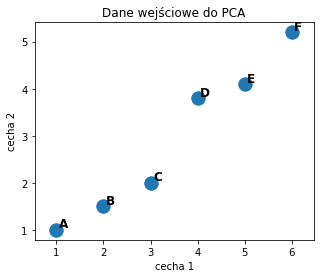

,x1,x2
A,1.0,1.0
B,2.0,1.5
C,3.0,2.0
D,4.0,3.8
E,5.0,4.1
F,6.0,5.2


In [2]:
fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(X[:,0], X[:,1], s=180)
for i, lab in enumerate(labels):
    ax.text(X[i,0]+0.05, X[i,1]+0.05, lab, fontsize=12, fontweight='bold')
ax.set_xlabel('cecha 1')
ax.set_ylabel('cecha 2')
ax.set_title('Dane wejściowe do PCA')
ax.axis('equal')
plt.show()

display(pd.DataFrame(X, index=labels, columns=['x1','x2']))


## 2. Centrowanie danych

PCA zaczyna od odjęcia średniej:

$$
\mu=\frac{1}{n}\sum_{i=1}^n x_i.
$$

Następnie:

$$
X_c = X - \mu.
$$


Średnia: $\mu = (3.500, 2.933)$

,x1 centered,x2 centered
A,-2.5,-1.933
B,-1.5,-1.433
C,-0.5,-0.933
D,0.5,0.867
E,1.5,1.167
F,2.5,2.267


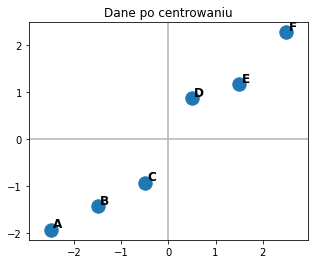

In [3]:
mu = X.mean(axis=0)
Xc = X - mu
display(Markdown(f"Średnia: $\\mu = ({mu[0]:.3f}, {mu[1]:.3f})$"))
display(pd.DataFrame(Xc, index=labels, columns=['x1 centered','x2 centered']).round(3))

fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(Xc[:,0], Xc[:,1], s=180)
for i, lab in enumerate(labels):
    ax.text(Xc[i,0]+0.05, Xc[i,1]+0.05, lab, fontsize=12, fontweight='bold')
ax.axhline(0, color='0.7'); ax.axvline(0, color='0.7')
ax.set_title('Dane po centrowaniu')
ax.axis('equal')
plt.show()


## 3. Macierz kowariancji

Macierz kowariancji:

$$
C=\frac{1}{n-1}X_c^T X_c.
$$

Dla dwóch cech ma postać:

$$
C=
\begin{bmatrix}
\operatorname{Var}(x_1) & \operatorname{Cov}(x_1,x_2)\\
\operatorname{Cov}(x_2,x_1) & \operatorname{Var}(x_2)
\end{bmatrix}.
$$

Interpretacja:

- $C_{11}$: wariancja pierwszej cechy,
- $C_{22}$: wariancja drugiej cechy,
- $C_{12}=C_{21}$: kowariancja między cechami.

Jeśli $C_{12}>0$, cechy mają tendencję do wspólnego wzrostu.
Jeśli $C_{12}<0$, jedna cecha rośnie, gdy druga maleje.
Jeśli $C_{12}\approx 0$, nie ma silnej liniowej współzmienności.

To właśnie z tej macierzy PCA wyznacza nowe osie.

In [4]:
C = Xc.T @ Xc / (len(X)-1)
display(pd.DataFrame(C, index=['x1','x2'], columns=['x1','x2']).round(4))


,x1,x2
x1,3.50,3.0600
x2,3.06,2.7827


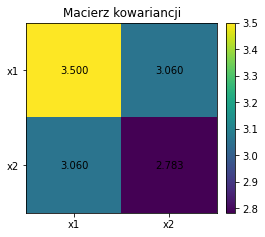

In [5]:
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(C)
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['x1', 'x2'])
ax.set_yticklabels(['x1', 'x2'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{C[i,j]:.3f}", ha="center", va="center")
ax.set_title("Macierz kowariancji")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## 4. Wektory własne i wartości własne

PCA rozwiązuje:

$$
C v = \lambda v.
$$

- Wektor własny $v$ mówi o kierunku.
- Wartość własna $\lambda$ mówi, ile wariancji jest w tym kierunku.

Pierwsza główna składowa to kierunek z największą wartością własną.


### Dlaczego wektory własne są kierunkami PCA?

Jeżeli wybierzemy dowolny wektor jednostkowy $v$, to współrzędne punktów po rzucie mają postać

$$
z = X_c v.
$$

Wariancja po takim rzucie wynosi

$$
\operatorname{Var}(z)=v^T C v.
$$

PCA szuka więc kierunku $v$, dla którego $v^T C v$ jest największe przy warunku $\|v\|=1$.

Rozwiązaniem są wektory własne macierzy $C$.
Największa wartość własna daje kierunek największej wariancji.

,wartość własna,wektor_x1,wektor_x2
PC1,6.2223,-0.7471,-0.6647
PC2,0.0604,0.6647,-0.7471


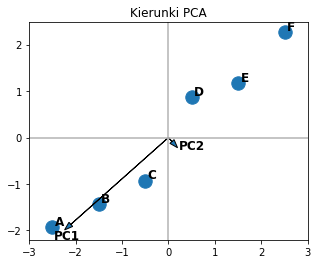

In [6]:
vals, vecs = np.linalg.eigh(C)
order = np.argsort(vals)[::-1]
vals = vals[order]
vecs = vecs[:, order]

display(pd.DataFrame({
    'wartość własna': vals,
    'wektor_x1': vecs[0],
    'wektor_x2': vecs[1],
}, index=['PC1','PC2']).round(4))

fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(Xc[:,0], Xc[:,1], s=180)
for i, lab in enumerate(labels):
    ax.text(Xc[i,0]+0.05, Xc[i,1]+0.05, lab, fontsize=12, fontweight='bold')
for k in range(2):
    v = vecs[:,k]
    scale = np.sqrt(vals[k])*1.2
    ax.arrow(0,0, scale*v[0], scale*v[1], head_width=0.12, length_includes_head=True)
    ax.text(scale*v[0]*1.1, scale*v[1]*1.1, f"PC{k+1}", fontsize=12, fontweight='bold')
ax.axhline(0, color='0.7'); ax.axvline(0, color='0.7')
ax.set_title('Kierunki PCA')
ax.axis('equal')
plt.show()


## 4a. Ile wariancji wyjaśnia PC1?

Wartości własne można zamienić na procent wyjaśnionej wariancji:

$$
r_k=\frac{\lambda_k}{\sum_j \lambda_j}.
$$

Jeśli $r_1$ jest bliskie $1$, to znaczy, że pierwszy kierunek PCA opisuje prawie cały rozrzut danych.

,wartość własna,udział wariancji,udział wariancji [%]
PC1,6.222,0.99,99.039
PC2,0.060,0.01,0.961


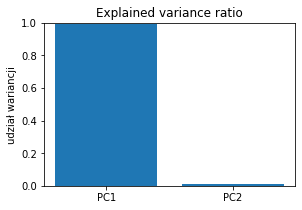

In [7]:
ratio = vals / vals.sum()
display(pd.DataFrame({
    "wartość własna": vals,
    "udział wariancji": ratio,
    "udział wariancji [%]": 100 * ratio,
}, index=["PC1", "PC2"]).round(3))

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.bar(["PC1", "PC2"], ratio)
ax.set_ylim(0, 1)
ax.set_ylabel("udział wariancji")
ax.set_title("Explained variance ratio")
plt.show()

## 5. Projekcja na PC1

Projekcja punktu na pierwszy kierunek:

$$
 z_i = x_{c,i}^T v_1.
$$

To daje reprezentację 1D.


,PC1 coordinate
A,3.1529
B,2.0734
C,0.9939
D,-0.9496
E,-1.8962
F,-3.3744


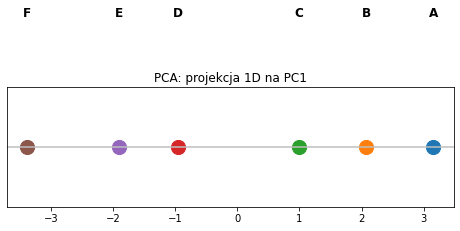

In [8]:
z1 = Xc @ vecs[:,0]
display(pd.DataFrame({'PC1 coordinate': z1}, index=labels).round(4))

fig, ax = plt.subplots(figsize=(8,2.2))
for i, lab in enumerate(labels):
    ax.scatter(z1[i], 0, s=200)
    ax.text(z1[i], 0.12, lab, ha='center', fontsize=12, fontweight='bold')
ax.axhline(0, color='0.75')
ax.set_yticks([])
ax.set_title('PCA: projekcja 1D na PC1')
plt.show()


## 5a. Co tracimy po redukcji do jednego wymiaru?

Po projekcji na PC1 każdy punkt ma tylko jedną współrzędną.

Możemy spróbować odtworzyć punkt w 2D jako

$$
\hat{x}_{c,i}=z_i v_1.
$$

Jeśli dane leżą prawie na jednej prostej, odtworzenie będzie dobre.
Jeśli dane mają istotny rozrzut także w kierunku PC2, odtworzenie będzie gorsze.

To jest intuicja za redukcją wymiaru:

> zachowujemy najważniejszy kierunek, ale świadomie tracimy część informacji.

,błąd odtworzenia po PC1
A,0.2172
B,0.0739
C,0.3650
D,0.3152
E,0.1254
F,0.0318


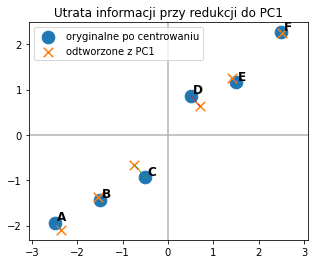

In [9]:
Xc_hat = np.outer(z1, vecs[:, 0])
reconstruction_error = np.linalg.norm(Xc - Xc_hat, axis=1)

display(pd.DataFrame({
    "błąd odtworzenia po PC1": reconstruction_error
}, index=labels).round(4))

fig, ax = plt.subplots(figsize=(5,4))
ax.scatter(Xc[:,0], Xc[:,1], s=160, label="oryginalne po centrowaniu")
ax.scatter(Xc_hat[:,0], Xc_hat[:,1], s=90, marker="x", label="odtworzone z PC1")
for i, lab in enumerate(labels):
    ax.plot([Xc[i,0], Xc_hat[i,0]], [Xc[i,1], Xc_hat[i,1]], linestyle="--", linewidth=1)
    ax.text(Xc[i,0]+0.05, Xc[i,1]+0.05, lab, fontsize=12, fontweight='bold')
ax.axhline(0, color='0.7'); ax.axvline(0, color='0.7')
ax.set_title("Utrata informacji przy redukcji do PC1")
ax.axis("equal")
ax.legend()
plt.show()

## Uwaga praktyczna: centrowanie vs standaryzacja

PCA zawsze wymaga centrowania danych.

Ale czasem trzeba też zrobić standaryzację:

$$
x'=\frac{x-\mu}{\sigma}.
$$

Ma to znaczenie, gdy cechy mają różne jednostki albo bardzo różne skale.

Przykład:

- wzrost w centymetrach,
- dochód w złotówkach,
- wiek w latach.

Bez standaryzacji cecha o największej skali może sztucznie zdominować PCA.
W tym notebooku skale są podobne, więc wystarczy centrowanie.

## 6. PCA vs t-SNE vs UMAP

PCA:

$$
\text{znajdź liniowy kierunek największej wariancji.}
$$

t-SNE:

$$
\text{dopasuj macierz podobieństw } Q \text{ do } P \text{ przez KL}. 
$$

UMAP:

$$
\text{dopasuj fuzzy graf } Q \text{ do fuzzy grafu } P \text{ przez cross-entropy}. 
$$

Najważniejsze porównanie:

| Metoda | Czy jest liniowa? | Co zachowuje? | Co może być problemem? |
|---|---:|---|---|
| PCA | tak | globalną wariancję | nie rozwija struktur nieliniowych |
| t-SNE | nie | lokalne podobieństwa | odległości globalne bywają mylące |
| UMAP | nie | lokalny graf sąsiedztw | wynik zależy od grafu i parametrów |

PCA jest świetna do wyjaśniania liniowej geometrii.
t-SNE i UMAP są lepsze, gdy struktura danych jest lokalna albo nieliniowa.